In [1]:
import shap
# pip install xgboost, catboost, lightgbm
import xgboost
import lightgbm

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, recall_score, precision_score
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RandomizedSearchCV
from sklearn.impute import SimpleImputer, KNNImputer
from imblearn.pipeline import Pipeline
#from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.datasets import make_classification
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

In [2]:
df = pd.read_csv('student_dropout_dataset_v3.csv')
df.head(5)

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [3]:
df.describe()

,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00000,10000.00000,9500.000000,9500.000000,10000.00000,10000.000000,10000.00000,9500.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,21.02606,38377.247474,4.014592,81.73683,1.799700,30.17926,5.507147,2.308440,2.300057,2.298761,0.23540
std,2886.89568,2.13981,20496.232179,1.295450,8.22093,1.344307,11.91887,1.765951,1.061717,1.074407,1.072555,0.42427
min,1.00000,17.00000,25000.000000,0.500000,38.20000,0.000000,5.00000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,19.50000,25000.000000,3.160000,76.40000,1.000000,21.90000,4.300000,1.550000,1.520000,1.520000,0.00000
50%,5000.50000,21.00000,29740.500000,4.000000,81.80000,2.000000,30.20000,5.500000,2.350000,2.350000,2.350000,0.00000
75%,7500.25000,22.50000,44520.000000,4.870000,87.30000,3.000000,38.40000,6.700000,3.120000,3.150000,3.150000,0.00000
max,10000.00000,29.60000,316601.000000,8.980000,100.00000,8.000000,74.90000,10.000000,4.000000,4.000000,4.000000,1.00000


In [4]:
df.shape

(10000, 19)

In [5]:
df.dropna(inplace=True)

In [6]:
df.shape

(9020, 19)

In [7]:
df = df.drop(columns=['Student_ID'])


In [8]:
df.shape

(9020, 18)

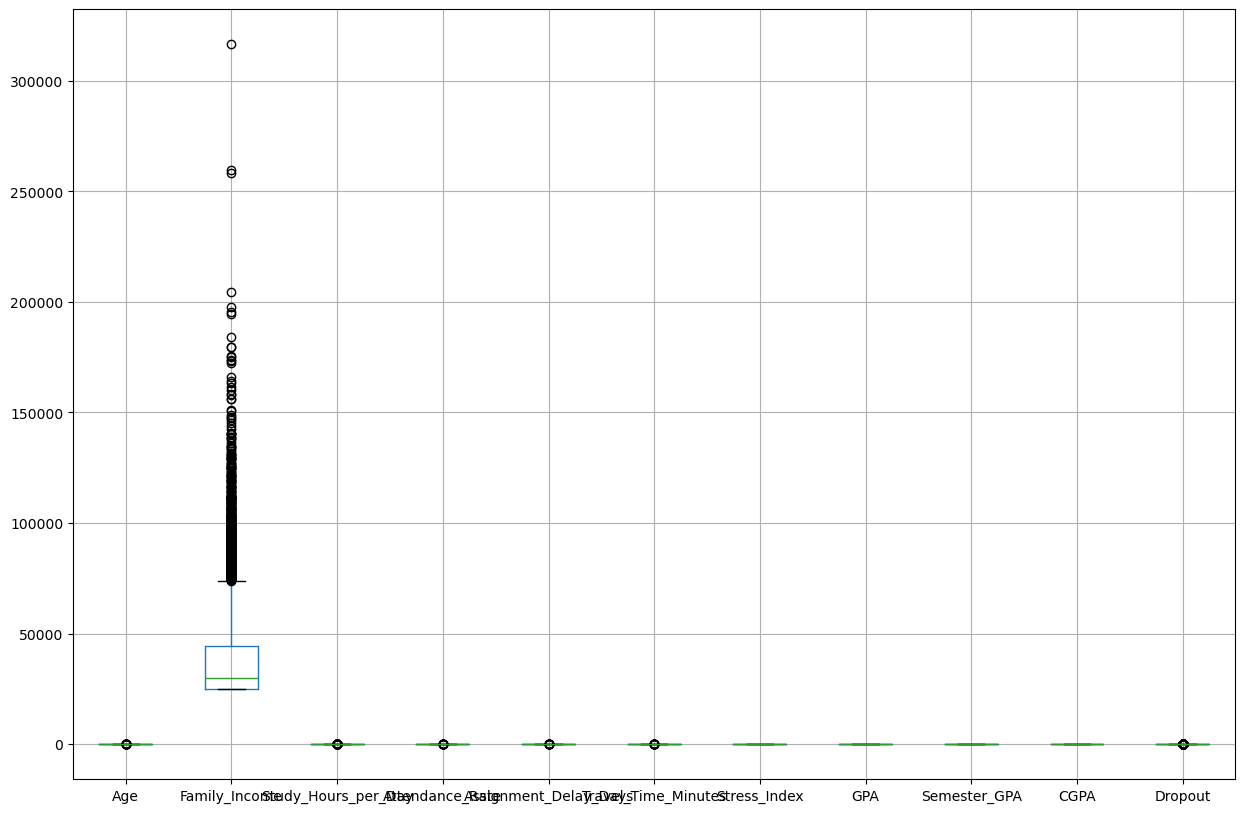

In [9]:
boxplot = df.boxplot(figsize=(15,10))

In [10]:
df.head(5)

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
4,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0
6,24.5,Male,25000.0,Yes,3.00,78.2,1,37.4,Yes,Yes,7.3,0.64,0.33,0.44,Year 4,CS,Bachelor,0


In [11]:
df["Internet_Access"] = df["Internet_Access"].replace({"Yes": 1, "No": 0})
df["Part_Time_Job"]   = df["Part_Time_Job"].replace({"Yes": 1, "No": 0})
df["Scholarship"]     = df["Scholarship"].replace({"Yes": 1, "No": 0})
df["Gender"]          = df["Gender"].replace({"Male": 1, "Female": 0})

C:\Users\Manos\AppData\Local\Temp\ipykernel_30460\2599807966.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Internet_Access"] = df["Internet_Access"].replace({"Yes": 1, "No": 0})
C:\Users\Manos\AppData\Local\Temp\ipykernel_30460\2599807966.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Part_Time_Job"]   = df["Part_Time_Job"].replace({"Yes": 1, "No": 0})
C:\Users\Manos\AppData\Local\Temp\ipykernel_30460\2599807966.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future 

In [12]:
df.head(5)

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,22.1,1,25000.0,1,3.36,86.1,2,20.4,1,0,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,20.7,1,25000.0,1,4.30,68.0,2,44.0,0,0,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,22.4,1,40183.0,1,4.40,70.9,0,48.9,1,0,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
4,20.5,0,25319.0,1,4.19,75.7,1,23.0,0,0,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0
6,24.5,1,25000.0,1,3.00,78.2,1,37.4,1,1,7.3,0.64,0.33,0.44,Year 4,CS,Bachelor,0


In [13]:
ohe_cols = ['Semester', 'Department', 'Parental_Education']
df_encoded = pd.get_dummies(df, columns=ohe_cols, drop_first=True)

In [14]:
df_encoded.shape

(9020, 25)

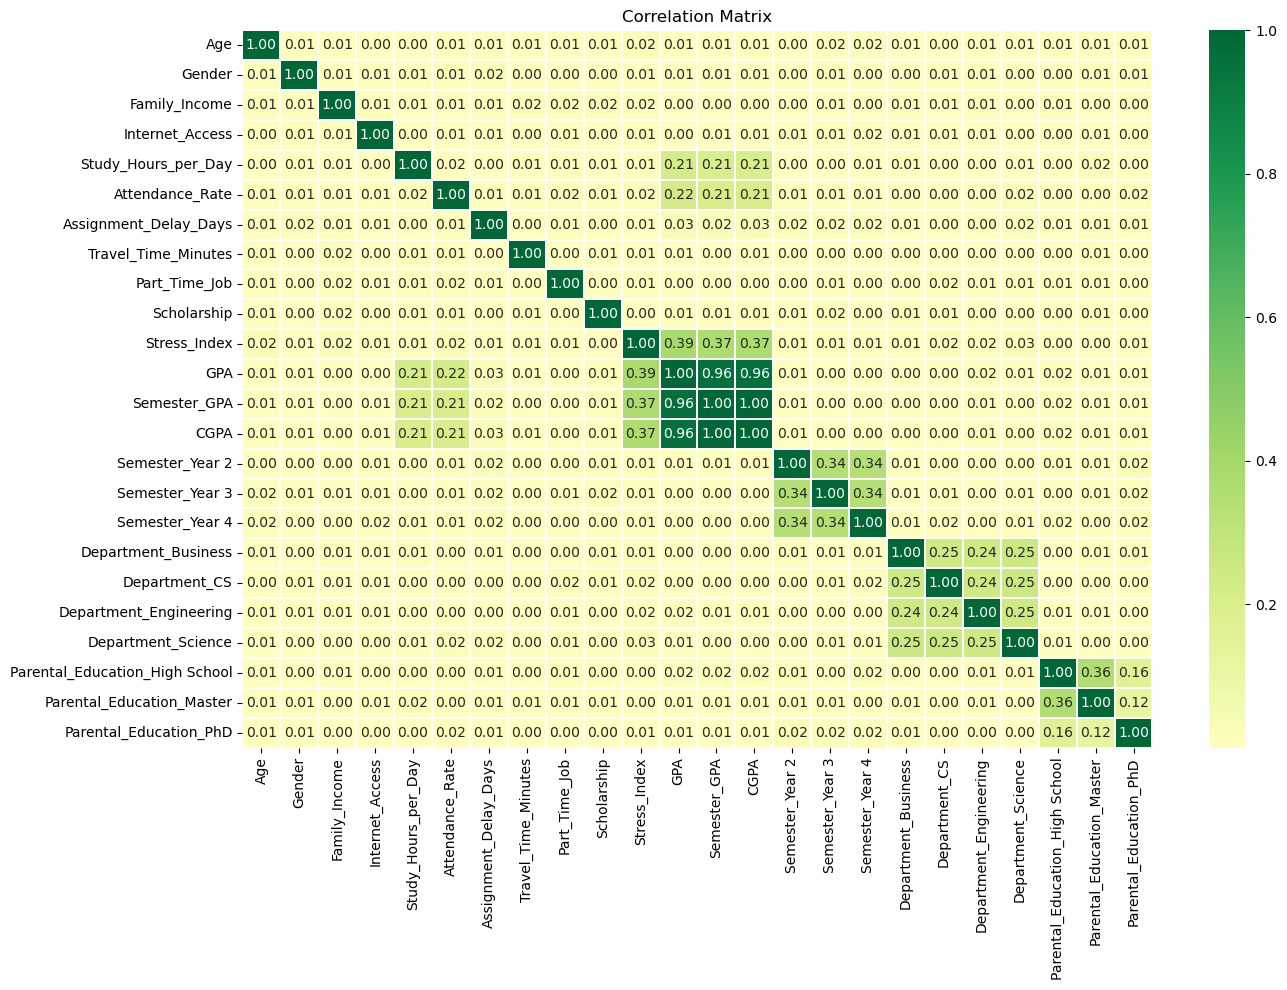

In [15]:
corr = df_encoded.drop(columns=['Dropout']).corr().abs()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.3)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [16]:
df_encoded = df_encoded.drop(columns=['GPA', 'Semester_GPA'])

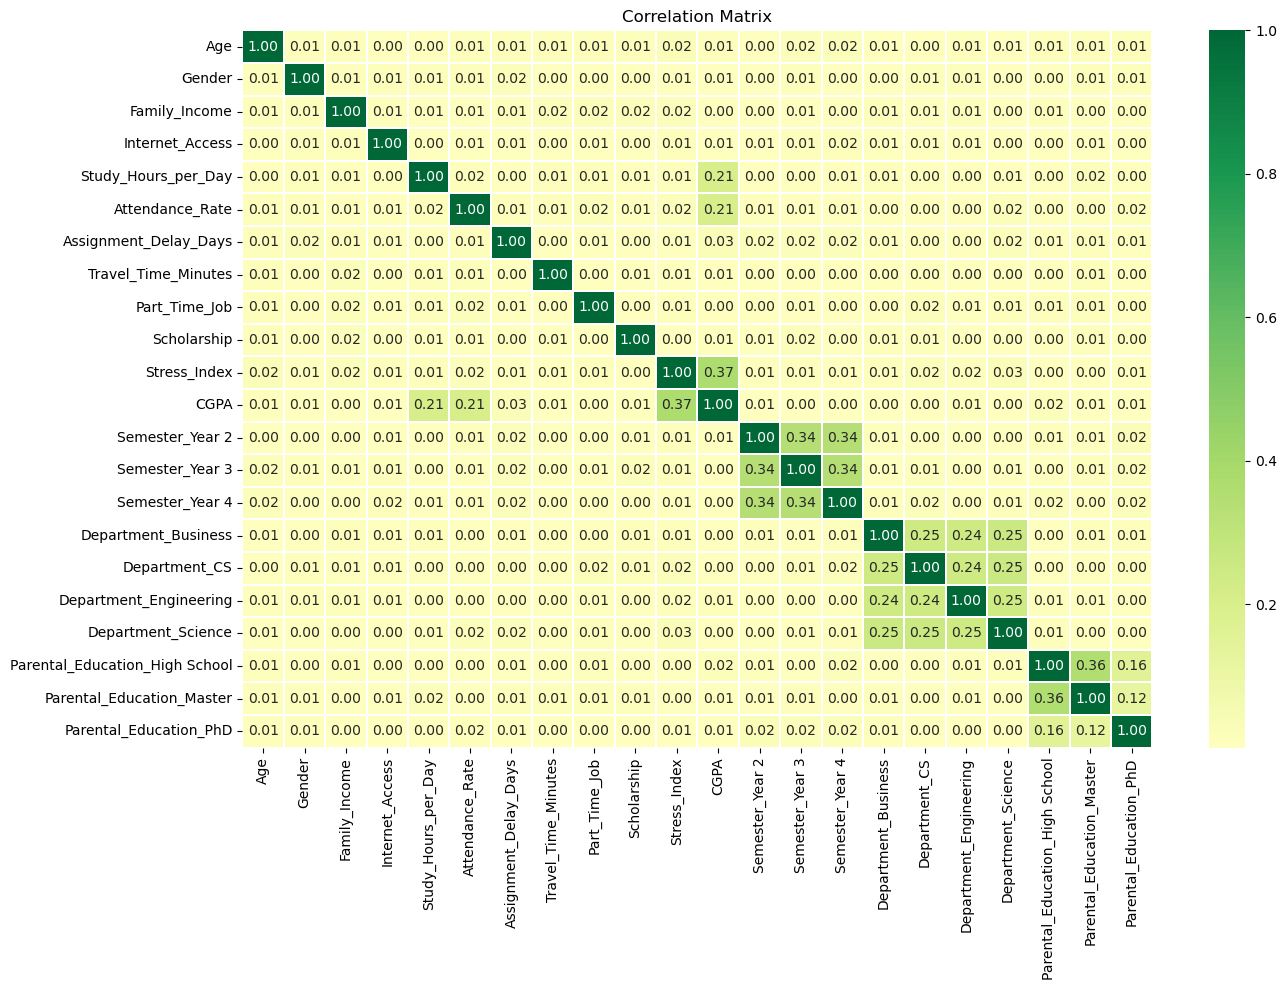

In [17]:
corr = df_encoded.drop(columns=['Dropout']).corr().abs()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.3)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [18]:
df_encoded['Dropout'].value_counts()

Dropout
0    6902
1    2118
Name: count, dtype: int64

In [19]:
df_encoded = df_encoded[df_encoded['Family_Income'] != df_encoded['Family_Income'].max()]


In [20]:
df_encoded.shape

(9019, 23)

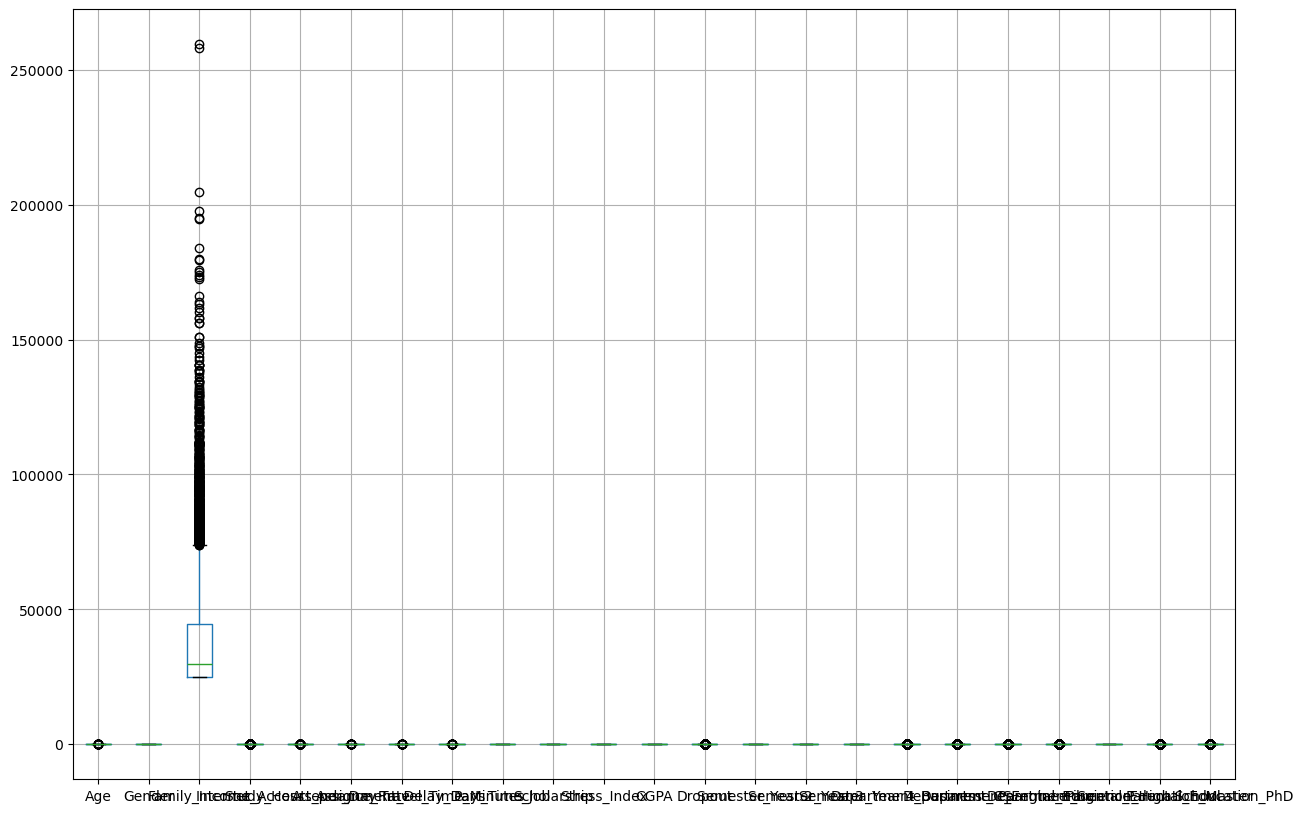

In [21]:
boxplot = df_encoded.boxplot(figsize=(15,10))
plt.show()


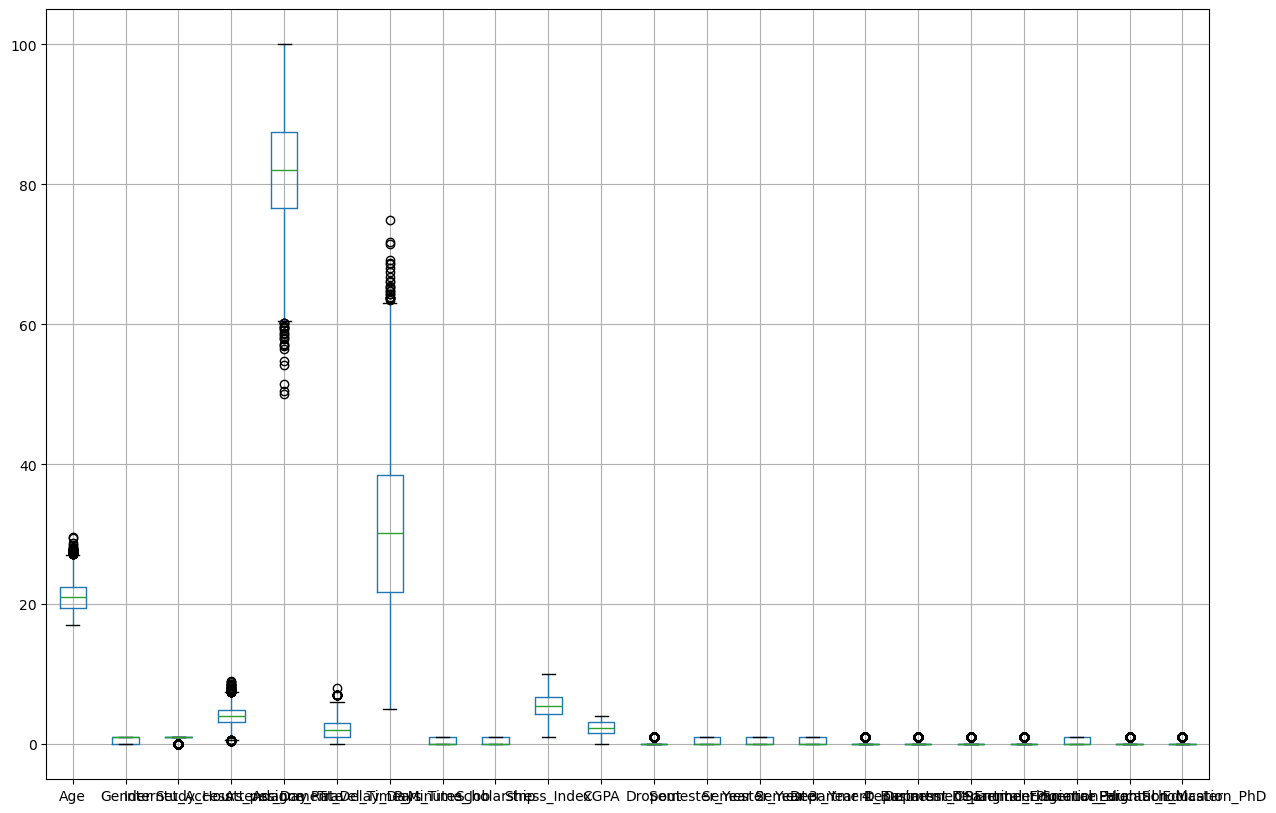

In [22]:
df_encoded.drop(columns=['Family_Income']).boxplot(figsize=(15,10))
plt.show()

In [23]:
### the name is df_encoded

In [24]:
df_new=df_encoded.copy()
X = df_new.drop("Dropout", axis=1)
y = df_new["Dropout"]

In [25]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
pipe = Pipeline([
    
    ('scaler', MinMaxScaler()),
    ('feature_selection', SelectKBest(score_func=f_classif)),
    ('classifier', LogisticRegression())   # placeholder
])

In [27]:
# Parameter grid
param_grid = [

    # Logistic Regression
    {
        'feature_selection__k': [5, 10, 15],
        'classifier': [LogisticRegression(max_iter=1000, class_weight='balanced')],
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__solver': ['liblinear', 'lbfgs']
    },

    # SVM
    {
        'feature_selection__k': [5, 10, 15],
        'classifier': [SVC(probability=True, class_weight='balanced')],
        'classifier__C': [0.1, 1, 10],
        'classifier__kernel': ['linear', 'rbf'],
        'classifier__gamma': ['scale', 'auto']
    },

    # Decision Tree
    {
        'feature_selection__k': [5, 10, 15],
        'classifier': [DecisionTreeClassifier(class_weight='balanced')],
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },

    # Random Forest
    {
        'feature_selection__k': [5, 10, 15],
        'classifier': [RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')],
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },

    # LightGBM (does not use class_weight, uses scale_pos_weight instead)
    {
        'feature_selection__k': [5, 10, 15],
        'classifier': [LGBMClassifier(n_estimators=100, random_state=42)],
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__num_leaves': [31, 50, 100],
        'classifier__learning_rate': [0.01, 0.05, 0.1],
        'classifier__scale_pos_weight': [y.value_counts()[0] / y.value_counts()[1]]  # balance positive class
    }
]

In [31]:
# GridSearch
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='f1',  # good for imbalanced datasets
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 384 candidates, totalling 1920 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', MinMaxScaler()),
                                       ('feature_selection', SelectKBest()),
                                       ('classifier', LogisticRegression())]),
             n_jobs=-1,
             param_grid=[{'classifier': [LogisticRegression(class_weight='balanced',
                                                            max_iter=1000)],
                          'classifier__C': [0.01, 0.1, 1, 10],
                          'classifier__solver': ['liblinear', 'lbfgs'],
                          'feature_selection__k': [5, 10, 15]},
                         {...
                          'classifier__min_samples_split': [2, 5, 10],
                          'feature_selection__k': [5, 10, 15]},
                         {'classifier': [LGBMClassifier(random_state=42)],
                          'classifier__learning_rate': [0.01, 0.05, 0.1],
                          'classifier__max_depth': [None, 5, 10, 20],
                          'classifier__num_leaves': [31, 50, 100],
                          'classifier__scale_pos_weight': [3.26027397260274],
                          'feature_selection__k': [5, 10, 15]}],
             scoring='f1', verbose=2)

In [32]:
# Evaluate
y_pred = grid.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Best Model:")
print(grid.best_estimator_)

print("\nBest Parameters:")
print(grid.best_params_)


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1357
           1       0.48      0.75      0.59       447

    accuracy                           0.74      1804
   macro avg       0.69      0.74      0.70      1804
weighted avg       0.80      0.74      0.76      1804

Best Model:
Pipeline(steps=[('scaler', MinMaxScaler()),
                ('feature_selection', SelectKBest(k=5)),
                ('classifier',
                 SVC(C=0.1, class_weight='balanced', probability=True))])

Best Parameters:
{'classifier': SVC(class_weight='balanced', probability=True), 'classifier__C': 0.1, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf', 'feature_selection__k': 5}


In [33]:
# Choose the sampler:
# Option 1: oversample the minority class
sampler = RandomOverSampler(random_state=42)

# Option 2: undersample the majority class
# sampler = RandomUnderSampler(random_state=42)

# Option 3:
# sampler =SMOTE(random_state=42)

# Pipeline with over/under-sampling and SelectKBest
pipe2 = Pipeline([
    ('scaler', MinMaxScaler()),
    ('feature_selection', SelectKBest(score_func=f_classif)),
    ('classifier', LogisticRegression())   # placeholder
])



In [35]:
grid = GridSearchCV(
    pipe2,
    param_grid,
    cv=3,
    scoring='f1',  # good for imbalanced datasets
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

Fitting 3 folds for each of 384 candidates, totalling 1152 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('scaler', MinMaxScaler()),
                                       ('feature_selection', SelectKBest()),
                                       ('classifier', LogisticRegression())]),
             n_jobs=-1,
             param_grid=[{'classifier': [LogisticRegression(class_weight='balanced',
                                                            max_iter=1000)],
                          'classifier__C': [0.01, 0.1, 1, 10],
                          'classifier__solver': ['liblinear', 'lbfgs'],
                          'feature_selection__k': [5, 10, 15]},
                         {...
                          'classifier__min_samples_split': [2, 5, 10],
                          'feature_selection__k': [5, 10, 15]},
                         {'classifier': [LGBMClassifier(random_state=42)],
                          'classifier__learning_rate': [0.01, 0.05, 0.1],
                          'classifier__max_depth': [None, 5, 10, 20],
                          'classifier__num_leaves': [31, 50, 100],
                          'classifier__scale_pos_weight': [3.26027397260274],
                          'feature_selection__k': [5, 10, 15]}],
             scoring='f1', verbose=2)

In [36]:
# Evaluate
y_pred = grid.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Best Model:")
print(grid.best_estimator_)

print("\nBest Parameters:")
print(grid.best_params_)


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.73      0.80      1357
           1       0.47      0.74      0.58       447

    accuracy                           0.73      1804
   macro avg       0.68      0.74      0.69      1804
weighted avg       0.79      0.73      0.75      1804

Best Model:
Pipeline(steps=[('scaler', MinMaxScaler()),
                ('feature_selection', SelectKBest()),
                ('classifier',
                 SVC(C=10, class_weight='balanced', kernel='linear',
                     probability=True))])

Best Parameters:
{'classifier': SVC(class_weight='balanced', probability=True), 'classifier__C': 10, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear', 'feature_selection__k': 10}


In [38]:
sampler =SMOTE(random_state=42)

pipe3 = Pipeline([

    ('scaler', MinMaxScaler()),
    ('sampler', sampler),  # replaces SMOTE
    ('feature_selection', SelectKBest(score_func=f_classif)),
    ('classifier', LogisticRegression())   # placeholder
])

In [39]:
grid = GridSearchCV(
    pipe3,
    param_grid,
    cv=3,
    scoring='f1',  # good for imbalanced datasets
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

Fitting 3 folds for each of 384 candidates, totalling 1152 fits


C:\Users\Manos\AppData\Local\miniconda3\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('scaler', MinMaxScaler()),
                                       ('sampler', SMOTE(random_state=42)),
                                       ('feature_selection', SelectKBest()),
                                       ('classifier', LogisticRegression())]),
             n_jobs=-1,
             param_grid=[{'classifier': [LogisticRegression(class_weight='balanced',
                                                            max_iter=1000)],
                          'classifier__C': [0.01, 0.1, 1, 10],
                          'classifier__solver': ['liblinear', 'lbfgs'],...
                          'classifier__min_samples_split': [2, 5, 10],
                          'feature_selection__k': [5, 10, 15]},
                         {'classifier': [LGBMClassifier(random_state=42)],
                          'classifier__learning_rate': [0.01, 0.05, 0.1],
                          'classifier__max_depth': [None, 5, 10, 20],
                          'classifier__num_leaves': [31, 50, 100],
                          'classifier__scale_pos_weight': [3.26027397260274],
                          'feature_selection__k': [5, 10, 15]}],
             scoring='f1', verbose=2)

In [40]:
# Evaluate
y_pred = grid.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Best Model:")
print(grid.best_estimator_)

print("\nBest Parameters:")
print(grid.best_params_)


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1357
           1       0.48      0.73      0.58       447

    accuracy                           0.74      1804
   macro avg       0.69      0.74      0.69      1804
weighted avg       0.79      0.74      0.75      1804

Best Model:
Pipeline(steps=[('scaler', MinMaxScaler()), ('sampler', SMOTE(random_state=42)),
                ('feature_selection', SelectKBest()),
                ('classifier',
                 LogisticRegression(C=1, class_weight='balanced', max_iter=1000,
                                    solver='liblinear'))])

Best Parameters:
{'classifier': LogisticRegression(class_weight='balanced', max_iter=1000), 'classifier__C': 1, 'classifier__solver': 'liblinear', 'feature_selection__k': 10}


In [41]:
## SMOTE

In [49]:
param_grid = [

    # Logistic Regression
    {
        'feature_selection__k': [5, 10, 15],
        'classifier': [LogisticRegression(max_iter=1000)],
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__solver': ['liblinear', 'lbfgs']
    },

    # SVM
    {
        'feature_selection__k': [5, 10, 15],
        'classifier': [SVC(probability=True)],
        'classifier__C': [0.1, 1, 10],
        'classifier__kernel': ['linear', 'rbf'],
        'classifier__gamma': ['scale', 'auto']
    },

    # Decision Tree
    {
        'feature_selection__k': [5, 10, 15],
        'classifier': [DecisionTreeClassifier()],
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },

    # Random Forest
    {
        'feature_selection__k': [5, 10, 15],
        'classifier': [RandomForestClassifier(n_estimators=100, random_state=42)],
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },

    # LightGBM
    {
        'feature_selection__k': [5, 10, 15],
        'classifier': [LGBMClassifier(n_estimators=100, random_state=42)],
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__num_leaves': [31, 50, 100],
        'classifier__learning_rate': [0.01, 0.05, 0.1]
    }
]

In [50]:
pipe4 = Pipeline([

    ('scaler', MinMaxScaler()),
    ('sampler', sampler),  # replaces SMOTE
    ('feature_selection', SelectKBest(score_func=f_classif)),
    ('classifier', LogisticRegression())   # placeholder
])

In [51]:
grid = GridSearchCV(
    pipe4,
    param_grid,
    cv=3,
    scoring='f1',  # good for imbalanced datasets
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

Fitting 3 folds for each of 384 candidates, totalling 1152 fits


C:\Users\Manos\AppData\Local\miniconda3\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('scaler', MinMaxScaler()),
                                       ('sampler', SMOTE(random_state=42)),
                                       ('feature_selection', SelectKBest()),
                                       ('classifier', LogisticRegression())]),
             n_jobs=-1,
             param_grid=[{'classifier': [LogisticRegression(max_iter=1000)],
                          'classifier__C': [0.01, 0.1, 1, 10],
                          'classifier__solver': ['liblinear', 'lbfgs'],
                          'feature_selection__k': [...
                          'classifier__max_depth': [None, 5, 10, 20],
                          'classifier__min_samples_leaf': [1, 2, 4],
                          'classifier__min_samples_split': [2, 5, 10],
                          'feature_selection__k': [5, 10, 15]},
                         {'classifier': [LGBMClassifier(random_state=42)],
                          'classifier__learning_rate': [0.01, 0.05, 0.1],
                          'classifier__max_depth': [None, 5, 10, 20],
                          'classifier__num_leaves': [31, 50, 100],
                          'feature_selection__k': [5, 10, 15]}],
             scoring='f1', verbose=2)

In [54]:
# Evaluate
y_pred = grid.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Best Model:")
print(grid.best_estimator_)

print("\nBest Parameters:")
print(grid.best_params_)


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1357
           1       0.48      0.73      0.58       447

    accuracy                           0.74      1804
   macro avg       0.69      0.74      0.69      1804
weighted avg       0.79      0.74      0.75      1804

Best Model:
Pipeline(steps=[('scaler', MinMaxScaler()), ('sampler', SMOTE(random_state=42)),
                ('feature_selection', SelectKBest()),
                ('classifier',
                 LogisticRegression(C=1, max_iter=1000, solver='liblinear'))])

Best Parameters:
{'classifier': LogisticRegression(max_iter=1000), 'classifier__C': 1, 'classifier__solver': 'liblinear', 'feature_selection__k': 10}


In [ ]:
## try select from model 

In [55]:
param_grid = [

    # Logistic Regression
    {
        'feature_selection__threshold': ['mean', 'median'], 
        'classifier': [LogisticRegression(max_iter=1000)],
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__solver': ['liblinear', 'lbfgs']
    },

    # SVM
    {
        'feature_selection__threshold': ['mean', 'median'],
        'classifier': [SVC(probability=True)],
        'classifier__C': [0.1, 1, 10],
        'classifier__kernel': ['linear', 'rbf'],
        'classifier__gamma': ['scale', 'auto']
    },

    # Decision Tree
    {
        'feature_selection__threshold': ['mean', 'median'],
        'classifier': [DecisionTreeClassifier()],
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },

    # Random Forest
    {
        'feature_selection__threshold': ['mean', 'median'],
        'classifier': [RandomForestClassifier(n_estimators=100, random_state=42)],
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },

    # LightGBM
    {
        'feature_selection__threshold': ['mean', 'median'],
        'classifier': [LGBMClassifier(n_estimators=100, random_state=42)],
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__num_leaves': [31, 50, 100],
        'classifier__learning_rate': [0.01, 0.05, 0.1]
    }
]

In [56]:
pipe5 = Pipeline([

    ('sampler', sampler),  # replaces SMOTE
    ('feature_selection', 
 SelectFromModel(
     LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)
 )),
    ('classifier', LogisticRegression())   # placeholder
])

In [57]:
grid = GridSearchCV(
    pipe5,
    param_grid,
    cv=3,
    scoring='f1',  # good for imbalanced datasets
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

Fitting 3 folds for each of 256 candidates, totalling 768 fits


C:\Users\Manos\AppData\Local\miniconda3\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('sampler', SMOTE(random_state=42)),
                                       ('feature_selection',
                                        SelectFromModel(estimator=LogisticRegression(max_iter=1000,
                                                                                     penalty='l1',
                                                                                     solver='liblinear'))),
                                       ('classifier', LogisticRegression())]),
             n_jobs=-1,
             param_grid=[{'classifier': [LogisticRegression(max_iter=1000)],
                          'classifier__C': [0.01, 0.1, 1, 10],
                          'classifier__s...
                          'classifier__min_samples_leaf': [1, 2, 4],
                          'classifier__min_samples_split': [2, 5, 10],
                          'feature_selection__threshold': ['mean', 'median']},
                         {'classifier': [LGBMClassifier(random_state=42)],
                          'classifier__learning_rate': [0.01, 0.05, 0.1],
                          'classifier__max_depth': [None, 5, 10, 20],
                          'classifier__num_leaves': [31, 50, 100],
                          'feature_selection__threshold': ['mean', 'median']}],
             scoring='f1', verbose=2)

In [58]:
# Evaluate
y_pred = grid.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Best Model:")
print(grid.best_estimator_)

print("\nBest Parameters:")
print(grid.best_params_)


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.76      0.81      1357
           1       0.48      0.70      0.57       447

    accuracy                           0.74      1804
   macro avg       0.68      0.73      0.69      1804
weighted avg       0.78      0.74      0.75      1804

Best Model:
Pipeline(steps=[('sampler', SMOTE(random_state=42)),
                ('feature_selection',
                 SelectFromModel(estimator=LogisticRegression(max_iter=1000,
                                                              penalty='l1',
                                                              solver='liblinear'),
                                 threshold='median')),
                ('classifier',
                 RandomForestClassifier(max_depth=5, min_samples_leaf=4,
                                        random_state=42))])

Best Parameters:
{'classifier': RandomForestClassifier(random_state=42), 'classifier__max_

In [59]:
# let's try f1 score for class 1

In [63]:
param_grid = [

    # Logistic Regression
    {
        'feature_selection__threshold': ['mean', 'median'], 
        'classifier': [LogisticRegression(max_iter=1000)],
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__solver': ['liblinear', 'lbfgs']
    },

    # SVM
    {
        'feature_selection__threshold': ['mean', 'median'],
        'classifier': [SVC(probability=True)],
        'classifier__C': [0.1, 1, 10],
        'classifier__kernel': ['linear', 'rbf'],
        'classifier__gamma': ['scale', 'auto']
    },

    # Decision Tree
    {
        'feature_selection__threshold': ['mean', 'median'],
        'classifier': [DecisionTreeClassifier()],
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },

    # Random Forest
    {
        'feature_selection__threshold': ['mean', 'median'],
        'classifier': [RandomForestClassifier(n_estimators=100, random_state=42)],
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },

    # LightGBM
    {
        'feature_selection__threshold': ['mean', 'median'],
        'classifier': [LGBMClassifier(n_estimators=100, random_state=42)],
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__num_leaves': [31, 50, 100],
        'classifier__learning_rate': [0.01, 0.05, 0.1]
    }
]

In [65]:
pipe6 = Pipeline([

    ('sampler', sampler),  # replaces SMOTE
    ('feature_selection', 
 SelectFromModel(
     LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)
 )),
    ('classifier', LogisticRegression())   # placeholder
])

In [60]:
from sklearn.metrics import make_scorer, f1_score

In [67]:
f1_class1 = make_scorer(f1_score, pos_label=1)

grid = GridSearchCV(
    pipe6,
    param_grid,
    cv=3,
    scoring=f1_class1,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

Fitting 3 folds for each of 256 candidates, totalling 768 fits


C:\Users\Manos\AppData\Local\miniconda3\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('sampler', SMOTE(random_state=42)),
                                       ('feature_selection',
                                        SelectFromModel(estimator=LogisticRegression(max_iter=1000,
                                                                                     penalty='l1',
                                                                                     solver='liblinear'))),
                                       ('classifier', LogisticRegression())]),
             n_jobs=-1,
             param_grid=[{'classifier': [LogisticRegression(max_iter=1000)],
                          'classifier__C': [0.01, 0.1, 1, 10],
                          'classifier__s...
                          'classifier__min_samples_split': [2, 5, 10],
                          'feature_selection__threshold': ['mean', 'median']},
                         {'classifier': [LGBMClassifier(random_state=42)],
                          'classifier__learning_rate': [0.01, 0.05, 0.1],
                          'classifier__max_depth': [None, 5, 10, 20],
                          'classifier__num_leaves': [31, 50, 100],
                          'feature_selection__threshold': ['mean', 'median']}],
             scoring=make_scorer(f1_score, response_method='predict', pos_label=1),
             verbose=2)

In [68]:
# Evaluate
y_pred = grid.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Best Model:")
print(grid.best_estimator_)

print("\nBest Parameters:")
print(grid.best_params_)


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.76      0.81      1357
           1       0.48      0.70      0.57       447

    accuracy                           0.74      1804
   macro avg       0.68      0.73      0.69      1804
weighted avg       0.78      0.74      0.75      1804

Best Model:
Pipeline(steps=[('sampler', SMOTE(random_state=42)),
                ('feature_selection',
                 SelectFromModel(estimator=LogisticRegression(max_iter=1000,
                                                              penalty='l1',
                                                              solver='liblinear'),
                                 threshold='median')),
                ('classifier',
                 RandomForestClassifier(max_depth=5, min_samples_leaf=4,
                                        random_state=42))])

Best Parameters:
{'classifier': RandomForestClassifier(random_state=42), 'classifier__max_

In [ ]:
### Add more models for class 1

In [71]:
pipe7 = Pipeline([
    
    ('scaler', MinMaxScaler()),
    ('feature_selection',SelectFromModel(
     LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)
 )),
    ('classifier', LogisticRegression())   # placeholder
])

In [72]:
# Parameter grid
param_grid = [

    # Logistic Regression
    {
        'feature_selection__threshold': ['mean', 'median'],
        'classifier': [LogisticRegression(max_iter=1000, class_weight='balanced')],
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__solver': ['liblinear', 'lbfgs']
    },

    # SVM
    {
        'feature_selection__threshold': ['mean', 'median'],
        'classifier': [SVC(probability=True, class_weight='balanced')],
        'classifier__C': [0.1, 1, 10],
        'classifier__kernel': ['linear', 'rbf'],
        'classifier__gamma': ['scale', 'auto']
    },

    # Decision Tree
    {
       'feature_selection__threshold': ['mean', 'median'],
        'classifier': [DecisionTreeClassifier(class_weight='balanced')],
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },

    # Random Forest
    {
        'feature_selection__threshold': ['mean', 'median'],
        'classifier': [RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')],
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },

    # LightGBM (does not use class_weight, uses scale_pos_weight instead)
    {
        'feature_selection__threshold': ['mean', 'median'],
        'classifier': [LGBMClassifier(n_estimators=100, random_state=42)],
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__num_leaves': [31, 50, 100],
        'classifier__learning_rate': [0.01, 0.05, 0.1],
        'classifier__scale_pos_weight': [y.value_counts()[0] / y.value_counts()[1]]  # balance positive class
    }
]

In [73]:


f1_class1 = make_scorer(f1_score, pos_label=1)

grid = GridSearchCV(
    pipe7,
    param_grid,
    cv=3,
    scoring=f1_class1,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

Fitting 3 folds for each of 256 candidates, totalling 768 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('scaler', MinMaxScaler()),
                                       ('feature_selection',
                                        SelectFromModel(estimator=LogisticRegression(max_iter=1000,
                                                                                     penalty='l1',
                                                                                     solver='liblinear'))),
                                       ('classifier', LogisticRegression())]),
             n_jobs=-1,
             param_grid=[{'classifier': [LogisticRegression(class_weight='balanced',
                                                            max_iter=1000)],
                          'classifier__C': [0.01, 0.1, 1, 10]...
                          'feature_selection__threshold': ['mean', 'median']},
                         {'classifier': [LGBMClassifier(random_state=42)],
                          'classifier__learning_rate': [0.01, 0.05, 0.1],
                          'classifier__max_depth': [None, 5, 10, 20],
                          'classifier__num_leaves': [31, 50, 100],
                          'classifier__scale_pos_weight': [3.26027397260274],
                          'feature_selection__threshold': ['mean', 'median']}],
             scoring=make_scorer(f1_score, response_method='predict', pos_label=1),
             verbose=2)

In [74]:
# Evaluate
y_pred = grid.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Best Model:")
print(grid.best_estimator_)

print("\nBest Parameters:")
print(grid.best_params_)


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1357
           1       0.48      0.74      0.59       447

    accuracy                           0.74      1804
   macro avg       0.69      0.74      0.70      1804
weighted avg       0.79      0.74      0.75      1804

Best Model:
Pipeline(steps=[('scaler', MinMaxScaler()),
                ('feature_selection',
                 SelectFromModel(estimator=LogisticRegression(max_iter=1000,
                                                              penalty='l1',
                                                              solver='liblinear'),
                                 threshold='median')),
                ('classifier',
                 LogisticRegression(C=0.1, class_weight='balanced',
                                    max_iter=1000))])

Best Parameters:
{'classifier': LogisticRegression(class_weight='balanced', max_iter=1000), 'classifier__C': 0

In [83]:
best_model = grid.best_estimator_

In [85]:
importances = best_model.feature_importances_

AttributeError: 'Pipeline' object has no attribute 'feature_importances_'

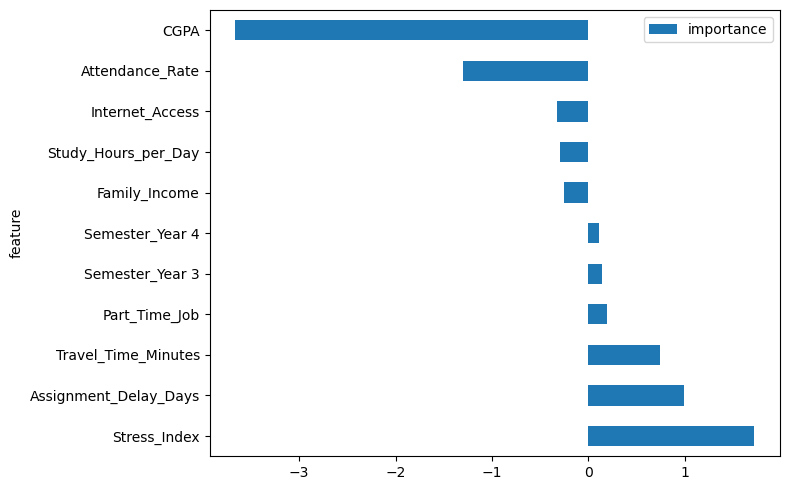

In [86]:
best_pipe = grid.best_estimator_

selector = best_pipe.named_steps['feature_selection']
classifier = best_pipe.named_steps['classifier']

selected_features = X_train.columns[selector.get_support()]

# LogisticRegression → coef_
if hasattr(classifier, 'coef_'):
    importance = classifier.coef_[0]
elif hasattr(classifier, 'feature_importances_'):
    importance = classifier.feature_importances_

feat_imp = pd.DataFrame({'feature': selected_features, 'importance': importance})
feat_imp = feat_imp.sort_values('importance', ascending=False)

feat_imp.plot(kind='barh', x='feature', y='importance', figsize=(8,5))
plt.tight_layout()
plt.show()